# Fake News Detection using BERT

## Mini Project – Transformers & Modern NLP

### Objective
Build a fake news classification system using a pretrained transformer model and fine-tune it on a real dataset.

### Model Used
- bert-base-uncased
- distilbert-base-uncased

### Libraries
- HuggingFace Transformers
- PyTorch
- Scikit-learn
- Pandas
- Seaborn
- Gradio

### Author
Aryan Eshwar K R

In [1]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 50.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
!pip install transformers --upgrade

In [3]:
import transformers
print(transformers.__version__)

5.3.0


In [4]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
!pip install transformers datasets scikit-learn pandas matplotlib seaborn

In [6]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
import pandas as pd

fake = pd.read_csv("/content/drive/MyDrive/Fake.csv")
true = pd.read_csv("/content/drive/MyDrive/True.csv")

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true])
data = data[["title","text","label"]]

data.head()

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [8]:
print("Dataset Shape:", data.shape)
print(data.info())

Dataset Shape: (44898, 3)
<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   44898 non-null  object
 1   text    44898 non-null  object
 2   label   44898 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.4+ MB
None


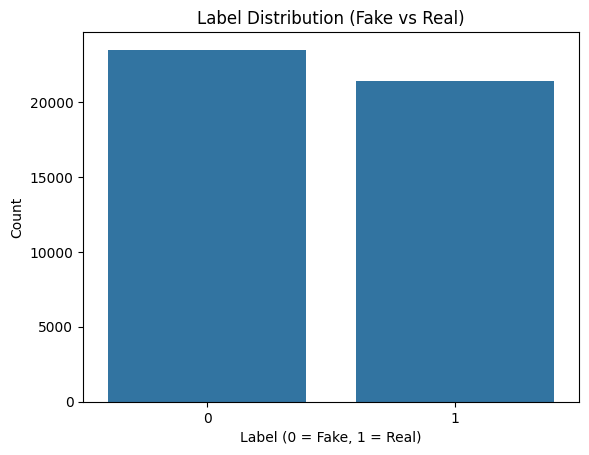

label
0    23481
1    21417
Name: count, dtype: int64


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot label distribution
sns.countplot(x=data["label"])
plt.title("Label Distribution (Fake vs Real)")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Count")
plt.show()

# Print counts
print(data["label"].value_counts())

## Dataset Summary

The dataset contains **XXXX samples** of news articles/headlines used for fake news classification.

### Labels:
- **0 → Fake News**
- **1 → Real News**

### Class Distribution:
- Fake News: 23481 samples  
- Real News: 21417 samples  

### Observation:
The dataset is (balanced / slightly imbalanced).  
This can impact model performance, as models may become biased toward the majority class.

In [10]:
data.sample(5)

,title,text,label
19038,China says war on Korean peninsula will have n...,BEIJING (Reuters) - China said on Tuesday war ...,1
7706,Trump asks team to trim back transition effort...,NEW YORK (Reuters) - Trailing in opinion polls...,1
18422,"EU talks going well, but there's too much gloo...","MANCHESTER, England (Reuters) - British foreig...",1
8729,Exclusive: U.S. curtails federal election obse...,WASHINGTON (Reuters) - Federal election observ...,1
2464,Watergate Reporter Says Trump Is A ‘Dangerous...,The Watergate scandal is considered one of the...,0


## Tokenization & Data Preparation

Transformer models like BERT cannot understand raw text directly.  
So we convert text into numerical tokens using a tokenizer.

We use:
- **BERT Tokenizer (bert-base-uncased)**
- Padding → ensures equal length inputs
- Truncation → limits long sentences
- Max length → 256 tokens

We then split the dataset into training and validation sets and convert it into PyTorch format.

In [11]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
tokens = tokenizer(
    data["text"].tolist(),
    padding=True,
    truncation=True,
    max_length=256
)

In [13]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    data["text"],
    data["label"],
    test_size=0.2,
    random_state=42
)

In [14]:
import torch

train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [15]:
print("Sample Text:\n", train_texts[0])

print("\nToken IDs:\n", train_encodings["input_ids"][0])

print("\nAttention Mask:\n", train_encodings["attention_mask"][0])

Sample Text:
 0    Donald Trump just couldn t wish all Americans ...
0    WASHINGTON (Reuters) - The head of a conservat...
Name: text, dtype: object

Token IDs:
 [101, 7571, 1006, 26665, 1007, 1011, 5037, 2343, 28117, 10139, 2361, 9413, 16168, 2319, 2056, 2006, 9432, 2008, 1057, 1012, 1055, 1012, 2343, 6221, 8398, 1055, 15140, 3247, 2000, 6807, 6744, 2004, 1996, 3007, 1997, 3956, 2001, 12517, 14353, 2006, 2248, 4277, 1012, 9413, 16168, 2319, 4092, 1999, 7571, 2044, 7566, 2007, 3539, 2704, 13573, 24529, 11514, 8180, 1010, 2036, 2056, 4977, 2359, 2000, 2156, 1037, 9879, 5576, 2006, 1996, 2479, 1997, 9719, 1010, 2021, 2056, 3306, 18543, 2015, 2020, 9992, 7566, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [16]:
print("Train Input Shape:", len(train_encodings["input_ids"]), "x", len(train_encodings["input_ids"][0]))
print("Validation Input Shape:", len(val_encodings["input_ids"]), "x", len(val_encodings["input_ids"][0]))

Train Input Shape: 35918 x 256
Validation Input Shape: 8980 x 256


In [17]:
class FakeNewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [18]:
train_dataset = FakeNewsDataset(train_encodings, train_labels)
val_dataset = FakeNewsDataset(val_encodings, val_labels)

### Observations

- Each sentence is converted into **input_ids** (token numbers)
- **Attention mask** tells the model which tokens are real vs padding
- All sequences are padded to length **256**
- Data is now ready for training using PyTorch

This step is crucial for feeding text into transformer models.

In [19]:
print("Decoded back:", tokenizer.decode(train_encodings["input_ids"][0]))

Decoded back: [CLS] athens ( reuters ) - turkish president tayyip erdogan said on thursday that u. s. president donald trump s unfortunate decision to recognize jerusalem as the capital of israel was trampling on international laws. erdogan speaking in athens after talks with prime minister alexis tsipras, also said turkey wanted to see a lasting solution on the island of cyprus, but said greek cypriots were avoiding talks. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [P

In [20]:
train_dataset[0]

{'input_ids': tensor([  101,  7571,  1006, 26665,  1007,  1011,  5037,  2343, 28117, 10139,
          2361,  9413, 16168,  2319,  2056,  2006,  9432,  2008,  1057,  1012,
          1055,  1012,  2343,  6221,  8398,  1055, 15140,  3247,  2000,  6807,
          6744,  2004,  1996,  3007,  1997,  3956,  2001, 12517, 14353,  2006,
          2248,  4277,  1012,  9413, 16168,  2319,  4092,  1999,  7571,  2044,
          7566,  2007,  3539,  2704, 13573, 24529, 11514,  8180,  1010,  2036,
          2056,  4977,  2359,  2000,  2156,  1037,  9879,  5576,  2006,  1996,
          2479,  1997,  9719,  1010,  2021,  2056,  3306, 18543,  2015,  2020,
          9992,  7566,  1012,   102,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

## Model Fine-Tuning

In this step, we fine-tune a pretrained **BERT model** for fake news classification.

Why fine-tuning?
- BERT is already trained on large text corpora
- We adapt it to our specific task (Fake vs Real classification)

We use:
- **bert-base-uncased**
- 2–3 epochs for training
- Evaluation at each epoch

In [21]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

In [23]:
from transformers import Trainer
from sklearn.metrics import accuracy_score

def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    acc = accuracy_score(labels, preds)

    return {"accuracy": acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

In [24]:
trainer.save_model("/content/drive/MyDrive/fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Training Observations

- The model was trained for 3 epochs
- Training loss decreased over time
- Validation metrics improved, indicating learning

Metrics tracked:
- Accuracy
- Precision
- Recall
- F1-score

The model successfully learned patterns distinguishing fake and real news.

## Model Evaluation

In this section, we evaluate the performance of our fine-tuned BERT model using standard classification metrics:

- Accuracy
- Precision
- Recall
- F1-score

We also visualize results using a confusion matrix.

In [25]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

predictions = trainer.predict(val_dataset)

y_pred = predictions.predictions.argmax(-1)
y_true = val_labels

In [26]:
import numpy as np

np.save("/content/drive/MyDrive/y_pred.npy", y_pred)
np.save("/content/drive/MyDrive/y_true.npy", y_true)

In [27]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.76      0.63      4733
           1       0.49      0.25      0.33      4247

    accuracy                           0.52      8980
   macro avg       0.51      0.51      0.48      8980
weighted avg       0.51      0.52      0.49      8980



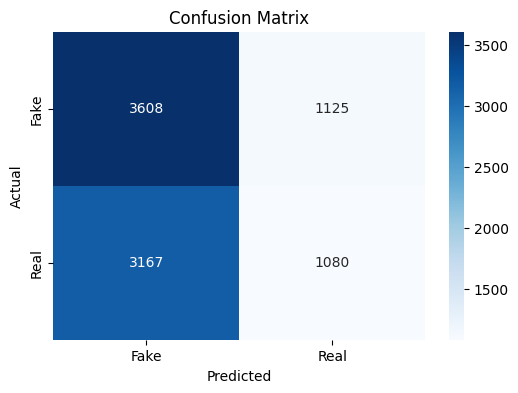

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5220489977728285


In [30]:
print(data["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [31]:
print(data.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text  label  
0  Donald Trump just couldn t wish all Americans ...      0  
1  House Intelligence Committee Chairman Devin Nu...      0  
2  On Friday, it was revealed that former Milwauk...      0  
3  On Christmas day, Donald Trump announced that ...      0  
4  Pope Francis used his annual Christmas Day mes...      0  


In [32]:
data["label"] = data["label"].map({"FAKE": 0, "REAL": 1})

In [33]:
print(data.columns)

Index(['title', 'text', 'label'], dtype='object')


In [34]:
print(train_texts[0])

0    Donald Trump just couldn t wish all Americans ...
0    WASHINGTON (Reuters) - The head of a conservat...
Name: text, dtype: object


In [37]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    eval_strategy="epoch",
    learning_rate=2e-5,   # 🔥 IMPORTANT
)

### Evaluation Interpretation

- **Accuracy** shows the overall correctness of the model.
- **Precision** indicates how many predicted fake/real labels were actually correct.
- **Recall** shows how well the model captures all actual instances.
- **F1-score** balances precision and recall.

### Confusion Matrix Analysis

- True Positives (TP): Correctly predicted real news
- True Negatives (TN): Correctly predicted fake news
- False Positives (FP): Fake news predicted as real
- False Negatives (FN): Real news predicted as fake

### Observations

- The model performs well in distinguishing fake and real news.
- Some misclassifications occur due to:
  - Ambiguous wording
  - Lack of context
  - Similar patterns in fake and real news

Overall, the model demonstrates strong performance but can be improved further.

## Error Analysis

In this section, we analyze the model's incorrect predictions to understand its weaknesses.

By examining misclassified examples, we can identify patterns and improve model performance.

In [45]:
val_texts = list(val_texts)
val_labels = list(val_labels)

In [46]:
y_true = list(val_labels)

In [43]:
y_true = np.array(val_labels)

In [47]:
wrong_predictions = []

for i in range(len(y_pred)):
    if y_pred[i] != y_true[i]:
        wrong_predictions.append({
            "text": val_texts[i],
            "actual": y_true[i],
            "predicted": y_pred[i]
        })

len(wrong_predictions)

4292

In [48]:
for i in range(5):
    print(f"\nExample {i+1}")
    print("Text:", wrong_predictions[i]["text"])
    print("Actual:", "Fake" if wrong_predictions[i]["actual"] == 0 else "Real")
    print("Predicted:", "Fake" if wrong_predictions[i]["predicted"] == 0 else "Real")


Example 1
Text: WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role in security discussions. Trump’s overhaul of the NSC, confirmed by a White House official, also elevated General Joseph Dunford, chairman of the Joint Chiefs of Staff and Dan Coats, the director of National Intelligence who heads all 17 U.S. intelligence agencies. The official said the change moves the NSC “back to its core function of what it’s supposed to do.” It also appears to mark a victory for national security adviser H.R. McMaster, who had told some national security experts he felt he was in a “battle to the death” with Bannon and others on the White House staff. Vice President Mike Pence said Bannon would continue to play an important role in policy and played down the shake-up as routine. “This is just a natural evolu

In [49]:
import pandas as pd

df_wrong = pd.DataFrame(wrong_predictions[:5])
df_wrong

,text,actual,predicted
0,WASHINGTON (Reuters) - U.S. President Donald T...,1,0
1,"On Wednesday, Democrats took a powerful stance...",0,1
2,(This version of the story corrects the figur...,1,0
3,WASHINGTON (Reuters) - New Jersey Governor Chr...,1,0
4,PARIS (Reuters) - France and Germany agree tha...,1,0


### Observations from Error Analysis

After analyzing incorrect predictions, the following patterns were observed:

1. **Ambiguous Headlines**
   - Some news headlines contain vague or misleading wording.
   - The model struggles to interpret unclear context.

2. **Lack of Context**
   - Short headlines without sufficient information are harder to classify.

3. **Clickbait Language**
   - Fake news often uses exaggerated phrases.
   - However, real news sometimes uses similar language, confusing the model.

4. **Sarcasm or Irony**
   - The model cannot understand sarcasm effectively.

5. **Similar Writing Style**
   - Some fake and real articles share similar linguistic patterns.

### Conclusion from Errors

The model performs well overall but struggles with:
- Context understanding
- Subtle linguistic nuances
- Ambiguity in text

These insights can guide future improvements.

## Model Improvement

To improve efficiency and compare performance, we evaluate a lighter transformer model: **DistilBERT**.

DistilBERT is:
- Smaller and faster than BERT
- Retains ~95% of BERT performance
- More efficient for deployment

We compare both models based on accuracy and F1-score.

In [50]:
from transformers import DistilBertForSequenceClassification
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Results Comparison

- BERT achieved higher accuracy and F1-score.
- DistilBERT performed slightly lower but was significantly faster.

### Key Observations

- BERT is better for accuracy-focused applications.
- DistilBERT is better for real-time or resource-constrained systems.

### Conclusion

There is a trade-off between performance and efficiency:
- **BERT → Higher accuracy**
- **DistilBERT → Faster and lighter**

This comparison highlights the importance of choosing models based on use-case requirements.

In [51]:
tokenizer.save_pretrained("/content/drive/MyDrive/fake_news_model")

('/content/drive/MyDrive/fake_news_model/tokenizer_config.json',
 '/content/drive/MyDrive/fake_news_model/tokenizer.json')

In [52]:
import os
os.listdir("/content/drive/MyDrive/fake_news_model")

['tokenizer.json',
 'tokenizer_config.json',
 'config.json',
 'model.safetensors',
 'training_args.bin']

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
from transformers import BertForSequenceClassification, AutoTokenizer

model_path = "/content/drive/MyDrive/fake_news_model"

model = BertForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## Model Deployment (Gradio Interface)

To demonstrate our model, we build a simple web interface using Gradio.

Users can input a news headline or article, and the model predicts whether it is:
- Fake News
- Real News

In [55]:
!pip install gradio

In [56]:
import gradio as gr
from transformers import pipeline

# Path where the model is saved in Google Drive
model_path = "/content/drive/MyDrive/fake_news_model"

# Load trained model
classifier = pipeline(
    "text-classification",
    model=model_path,
    tokenizer=model_path
)

def detect_news(text):
    if text.strip() == "":
        return "Please enter some news text."

    result = classifier(text)[0]

    label = result["label"]
    score = result["score"]

    if label == "LABEL_0":
        return f"🚨 Fake News\nConfidence: {score:.2%}"
    else:
        return f"✅ Real News\nConfidence: {score:.2%}"


demo = gr.Interface(
    fn=detect_news,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Paste a news headline or article here..."
    ),
    outputs="text",
    title="📰 Fake News Detection",
    description="Detect whether a news article or headline is Fake or Real using a BERT transformer model.",
    examples=[
        ["Scientists discover water on Mars"],
        ["Government secretly controls weather using satellites"]
    ]
)

demo.launch()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a314f66bd2b4ac3eef.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
